#**Proyecto DSS: Sistema Predictivo "Perrito Reciclado"**
**Materia:** Sistemas de Apoyo a la Toma de Decisiones

**Herramienta:** Google Colab (usando el entorno de Python)

## 1. Resumen General del Google Colabs
**Este cuaderno contiene el flujo de trabajo completo que se usó para el entrenamiento del "Cerebro o IA"** (Backend) **de nuestro DSS** (Sistema de Apoyo a la Toma de Decisiones) de la empresa ficticia "Perrito Reciclado".

Utilizamos técnicas de **Machine Learning Supervisado** para analizar el historial de clientes y generar un modelo capaz de predecir si un nuevo cliente será frecuente o no.


## 2. Conceptos Generales

#### **¿Qué es el Google Colab?**

**Google Colaboratory (o "Colab") es un entorno de desarrollo basado en la nube que permite escribir y ejecutar código en Python directamente en el navegador.**
Funciona sobre la tecnología de Jupyter Notebooks, facilitando la
combinación de código ejecutable, texto enriquecido, gráficos y ecuaciones en un solo documento.

**No requiere instalar Python, librerías ni gestionar entornos virtuales en las computadoras locales de cada miembro del equipo.** Todo está pre-instalado en la nube.

Al estar integrado con Google Drive, **permite que el equipo trabaje simultáneamente en el código, comparta resultados y deje comentarios, similar a un Google Doc.**

#### **¿Qué es el Machine Learning?**

Es una rama de la Inteligencia Artificial (IA) que **permite a las computadoras aprender sin ser programadas explícitamente para cada tarea.**


Normalmente cuando se programa de manera tradicional, uno le dice que hacer a la computadora, por ejemplo:

```
if calificacion >= 6:

print("Aprobado")

else:

print("Reprobaste, chale.")

```
Con Machine Learning tú le das los datos (Historial de clientes) y la computadora descubre las reglas por sí sola.

#### **¿Qué es el Machine Learning Supervisado?**

**Es el tipo de ML que hemos usado para el proyecto. Se llama "Supervisado" porque entrenamos al modelo con las respuestas correctas** (como un profesor que enseña con ejemplos resueltos).

#### **Cómo funciona:**

*   **Entrada (Input)**: Datos del cliente (Edad, Gasto, Mascota).
*   **Etiqueta (Output Esperado)**: La respuesta correcta (CLIENTE FRECUENTE = Sí).
*   **Entrenamiento**: La máquina busca la relación entre el Input y la Etiqueta.
*  **Predicción**: Cuando llega un cliente nuevo (sin etiqueta), la máquina aplica lo aprendido para adivinar la respuesta.

#**Paso 1 - Conexión y e importación de Datos**
Conectamos el entorno de ejecución a Google Drive para acceder a los archivos históricos de la empresa que ya se simplificaron y enfocaron solo en el proceso deseado (`Datos_Entrenamiento.xlsx`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Paso 2 - Entrenamiento del modelo robusto**
En esta etapa realizamos los siguientes paso:
1.  **Insertamos:** Leemos el Excel de Clientes.
2.  **Limpiamos:** Convertimos textos a números y eliminamos datos vacíos.
3.  **Transformación:** Transformamos variables categóricas (como "Perro", "Gato") en formato binario (0 y 1) que el algoritmo pueda entender y evitar que cree jerarquias falsas, usando el formato dummies.
4.  **Entrenamiento:** Alimentamos al algoritmo de la libreria Scikit-Learn `DecisionTreeClassifier` con los datos procesados.
5.  **Respaldo:** Guardamos el modelo (`.pkl`) para usarlo posteriormente en la Interfaz de Usuario.

Cargando datos...
Entrenando el modelo...

¡ÉXITO! EL MODELO SE ENTRENÓ CORRECTAMENTE
Archivos generados: 'modelo_perrito.pkl', 'columnas_modelo.pkl' y 'traductor_respuestas.pkl'


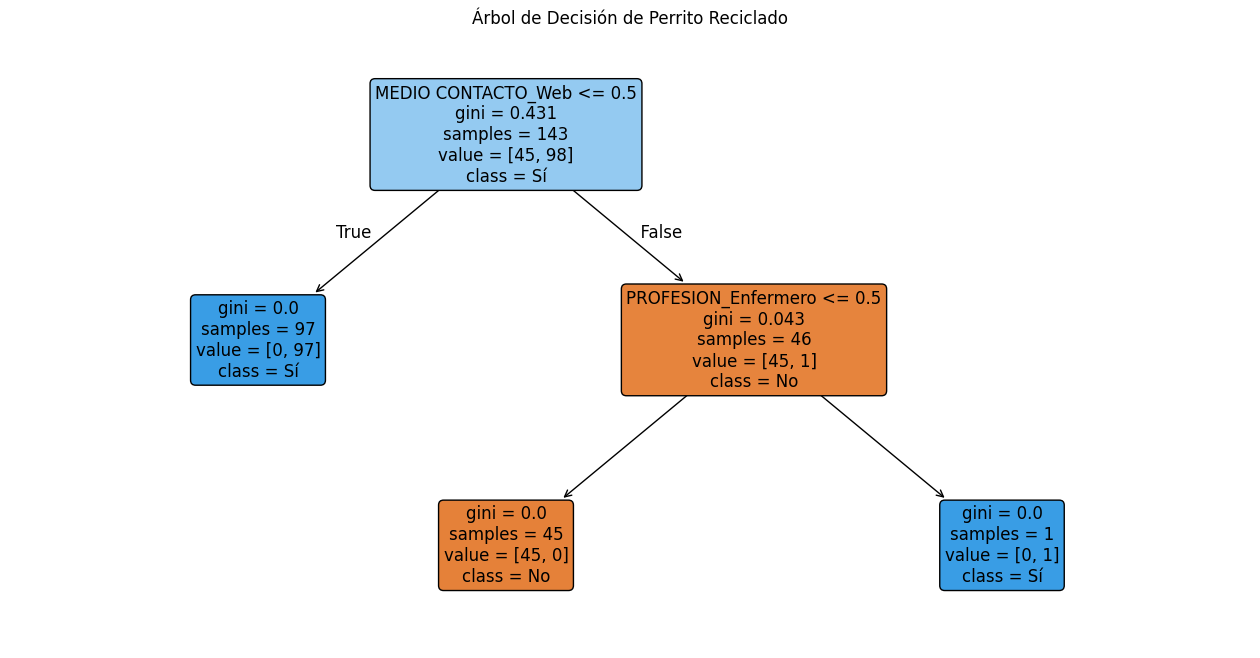

In [ ]:
# Modelo principal, diseñado para realizar las mejores predicciones posibles.
# Hola Maestra :D

# Importar librerías clave
import pandas as pd
import joblib ##Para guardar la IA entrenada en un archivo
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder ## Para convertir a valores binarios
import matplotlib.pyplot as plt

print("Cargando datos...")
# Leemos el archivo de entrenamiento para el árbol de Perrito Reciclado, específicamente la hoja de clientes.
df = pd.read_excel('/content/drive/MyDrive/Datos_Entrenamiento_Final.xlsx', sheet_name='CLIENTES')

# Limpiamos nombres de columnas (quitamos espacios molestos que vienen naturalmente en un archivo de excel)
df.columns = df.columns.str.strip()

# Seleccionado que datos usar
# Estas son las columnas que se usan para predecir si alguien compra o no (Parametros que el programa va a comparar)
# Definimos esto como valores dentro de un arreglo
columnas_entrada = ['EDAD', 'MEDIO CONTACTO', 'SEXO', 'TIPO MASCOTA',
                    'PROFESION', 'ESTADO CIVIL', 'CANTIDAD GASTADA',
                    'VECES COMPRADO EN LA TIENDA']

# Definimos la variable que se quiere predecir (Sí/No)
columna_objetivo = 'CLIENTE FRECUENTE'

# Borramos filas vacías que tenga el excel  para que el modelo no se confunda con datos vacíos
datos = df[columnas_entrada + [columna_objetivo]].dropna()

# Nos aseguramos de que todas las variables sean numericas convirtiendolas a ese formato
datos['EDAD'] = pd.to_numeric(datos['EDAD'], errors='coerce')
datos['CANTIDAD GASTADA'] = pd.to_numeric(datos['CANTIDAD GASTADA'], errors='coerce')

# Convertimos "Sí/No" a "1/0", establecemnos valores binarios a "Cliente frecuente" o "Cliente no frecuente".
le_target = LabelEncoder()
datos[columna_objetivo] = le_target.fit_transform(datos[columna_objetivo])

# Convertimos "Perro/Gato", "Soltero/Casado" a códigos numéricos
X = pd.get_dummies(datos[columnas_entrada], drop_first=False)
y = datos[columna_objetivo]

# Fase de entrenamiento (Del Árbol)
print("Entrenando el modelo...")
clf = DecisionTreeClassifier(random_state=42, max_depth=5) # Max depth es qué tan grande es el árbol, le damos chance de que pueda tomar más decisiones (preguntas) y que sea más preciso.
clf.fit(X, y) # El modelo comienza a analizar y aprender los partrones en nuesto Excel

# Exportando el modelo
# Archivos a usar para el Sistema Final, el modelado de la IA/Árbol de decisión, las columas del formato y el diccionario de correspondencia.
joblib.dump(clf, 'modelo_perrito.pkl')
# Las columnas y el formato de la tabla de Excel/DataFrame
joblib.dump(X.columns, 'columnas_modelo.pkl')
# Guarda un diccionario que corresponde la correspondencia exacta entre las categorías de texto ('Sí'/'No') y los valores numéricos (1/0) que usa el modelo.
joblib.dump(le_target, 'traductor_respuestas.pkl')

print("\n" + "="*40)
print("¡ÉXITO! EL MODELO SE ENTRENÓ CORRECTAMENTE")
print("="*40)
print("Archivos generados: 'modelo_perrito.pkl', 'columnas_modelo.pkl' y 'traductor_respuestas.pkl'")

# Dibujamos el arbol para observar los resultados del entrenamiento
plt.figure(figsize=(16,8))
plot_tree(clf, feature_names=X.columns, class_names=le_target.classes_, filled=True, rounded=True, fontsize=12)
plt.title("Árbol de Decisión de Perrito Reciclado")
plt.show()

#**Metodología y tecnologías usadas**
* **Algoritmo:** Árbol de Decisión / Clasificación con Árboles de Decisión (CART - Classification and Regression Trees).

**Un Árbol de Decisión es un algoritmo que separa tus datos haciendo preguntas de tipo Sí/No de manera secuencial.**

El algoritmo más usado en la actualidad para el entrenamiento de árboles de decisión se conoce como CART, o Árbol de Clasificación y Regresión por sus siglas en Inglés,  **es una de las técnicas de aprendizaje automático más populares y versátiles.**

Su nombre lo dice todo: crea una estructura similar a un árbol (raíz, ramas, hojas) para tomar decisiones o predecir resultados.

#### **¿Por qué se eligio CART?**

**Por que CART tiene el algoritmo específico que construye lo que queremos**, aunque puede hacer dos cosas:

*   **Clasificación**: Predice una categoría o etiqueta (ej: "Sí/No", "Perro/Gato"). **Este es el que estamos implementando para determinar si un cliente es frecuente o no.**
*   **Regresión**: Predice un número continuo (ej: "El precio de esta casa será $1.5 millones").

**CART es ideal para nuestro DSS es por que usa White Box**, a diferencia de las redes neuronales que son "cajas negras" difíciles de entender, un árbol te muestra exactamente por qué tomó una decisión, lo mostraremos mas adelante de manera gráfica.

**Además, no se necesitan tratar los datos; el árbol maneja bien datos numéricos (Edad) y categóricos (Mascota) juntos.**

Y para rematar, automáticamente pone las preguntas más importantes arriba, sin que tengamos que ajustar parámetros.

#### **¿Cómo construye el árbol?**
El algoritmo busca la mejor pregunta para dividir los datos usando métricas de "impureza" como Gini o Entropía.

Básicamente, busca la pregunta que deje los grupos resultantes lo más "puros" posible usando alguno de esos algoritmos matematicos para calcular el nivel de impuresa.

* **Librerías:**
    * `Pandas`: Es la herramienta más poderosa de Python para manipulación, análisis y limpieza de datos, capaz de leer el archivo de excel que se usa como entrenamiento de datos, borrando celdas vacías, convertir categorias a valores binarios, convertir columnas enteras de texto a números y almacenar el excel en matríces.

    * `Scikit-Learn`: Para la creación, entrenamiento y validación del modelo de IA, es la biblioteca de Machine Learning más popular y robusta del mundo para Python, contiene implementaciones eficientes de la gran mayoría de algoritmos de IA conocidos, básicamente nos permite implementar CART.

    * `Matplotlib`: librería base para creación de gráficos y visualización de datos en Python, básicamente permite la visualización gráfica del árbol.

    * `Joblib`: Nos permite guardar el modelo entrenado para exportarlo de Collab a un entorno local (VsCode en este caso).

#**Paso 3 - Prueba del modelo**
Para verificar que el sistema funciona antes de conectarlo a la interfaz visual, cargamos el modelo usando el archivo `.pkl`, simulamos la llegada de un cliente nuevo y le damos la salida que se espera en el producto final.

#### **Nota Técnica**

El modelo requiere que le enviemos la misma estructura de datos (columnas) con la que fue entrenado, asi como el diccionario que correlaciona los valores binarios (0 y 1) con las respuestas (Cliente frecuente y Cliente no frecuenta).

En este bloque de código realizamos una alineación de datos para asegurar compatibilidad.

In [ ]:
import pandas as pd
import joblib

## 1. Cargar el modelo entrenado y las columnas
print('Cargando el modelo IA...')
modelo_cargado = joblib.load('modelo_perrito.pkl')
columnas_modelo = joblib.load('columnas_modelo.pkl')
le_target = joblib.load('traductor_respuestas.pkl')

# 2. Rellanamos con datos nuevos de un cliente
# Simulamos lo que el usuario ingresaría en la interfaz
nuevo_cliente_raw = {
    'EDAD': [35],
    'CANTIDAD GASTADA': [300],
    'VECES COMPRADO EN LA TIENDA': [2],
    'MEDIO CONTACTO': ['Instagram'],
    'SEXO': ['F'],
    'TIPO MASCOTA': ['Perro'],
    'PROFESION': ['Ingeniero'],
    'ESTADO CIVIL': ['Soltera']
}

# Convertimos a DataFrame
input_df = pd.DataFrame(nuevo_cliente_raw)

# 3. Adaptamos datos
# Convertimos el input a dummies (igual que en el entrenamiento)
input_dummies = pd.get_dummies(input_df)

# Alineamos con las columnas que el modelo "conoce".
# Rellenamos con 0 las columnas que falten (ej: si el cliente es "Perro", la columna "Gato" será 0)
input_final = input_dummies.reindex(columns=columnas_modelo, fill_value=0)

# 4. Preddición del modelo
prediccion_num = modelo_cargado.predict(input_final)
probabilidad = modelo_cargado.predict_proba(input_final)

# Convertimos el número (0/1) de vuelta a texto (No/Sí)
resultado_texto = le_target.inverse_transform(prediccion_num)

# 5. Salida al usuario
print("-" * 30)
print(f"Resultado para el cliente: {resultado_texto[0]}")
print(f"Confianza del modelo: {probabilidad.max():.2%}")
print("-" * 30)

if resultado_texto[0] == 'Sí':
    print('ACCIÓN SUGERIDA: Aplicar estrategia de fidelización VIP.')
else:
    print('ACCIÓN SUGERIDA: Aplicar estrategia de retención básica.')

Cargando el modelo IA...
------------------------------
Resultado para el cliente: Sí
Confianza del modelo: 100.00%
------------------------------
ACCIÓN SUGERIDA: Aplicar estrategia de fidelización VIP.


#**Paso 4 - Modelo alternativo**
Segundo modelo creado en caso de necesitar mayor eficiencia a cambio de una menos precision en cuanto a predicciones.

Cargando datos...
Entrenando modelo simplificado...
¡Modelo entrenado y simplificado!


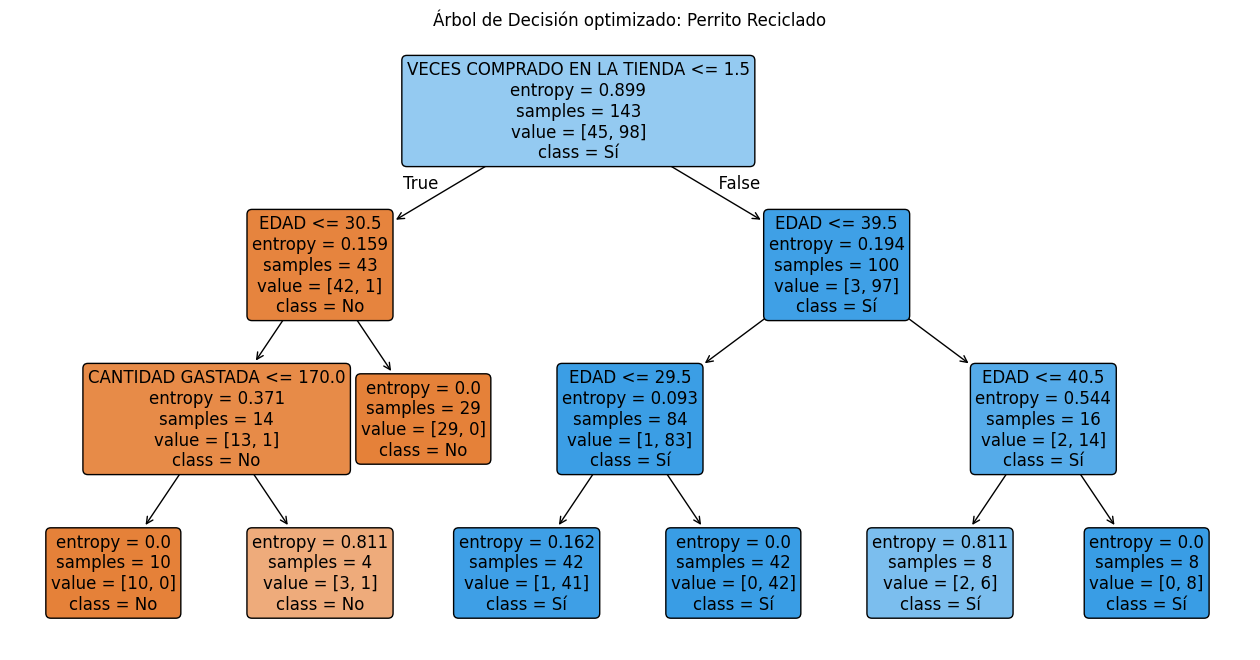

In [ ]:
# Exportar librerias
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Leer datos
print("Cargando datos...")
# Importamos el archivo de excel
df = pd.read_excel('/content/drive/MyDrive/Datos_Entrenamiento_Final.xlsx', sheet_name='CLIENTES')

# Limpieza básica de excel
df.columns = df.columns.str.strip()

#Se optimiza el arbol al usar menos variables a clasificar y verificar, lo vuelve más impreciso para predecir con exactitud.
columnas_entrada = ['EDAD', 'CANTIDAD GASTADA', 'VECES COMPRADO EN LA TIENDA']

columna_objetivo = 'CLIENTE FRECUENTE'

# Nos aseguramos de convertir todo a valores numéricos
datos = df[columnas_entrada + [columna_objetivo]].dropna()
datos['EDAD'] = pd.to_numeric(datos['EDAD'], errors='coerce')
datos['CANTIDAD GASTADA'] = pd.to_numeric(datos['CANTIDAD GASTADA'], errors='coerce')
datos['VECES COMPRADO EN LA TIENDA'] = pd.to_numeric(datos['VECES COMPRADO EN LA TIENDA'], errors='coerce')

# Convertir Objetivo a 0 y 1
le_target = LabelEncoder()
datos[columna_objetivo] = le_target.fit_transform(datos[columna_objetivo])

X = datos[columnas_entrada]
y = datos[columna_objetivo]

# Entrenamiento limitado
print("Entrenando modelo simplificado...")
# max_depth=3 hace que el árbol sea pequeño y legible (solo 3 niveles de preguntas), pero si aunmentamos la cantidad de datos de origen, se volvera mas impreciso
clf = DecisionTreeClassifier(random_state=42, max_depth=3, criterion='entropy')
clf.fit(X, y)

# Guardamos los modelos
joblib.dump(clf, 'modelo_perrito.pkl')
joblib.dump(X.columns, 'columnas_modelo.pkl')
joblib.dump(le_target, 'traductor_respuestas.pkl')

print("¡Modelo entrenado y simplificado!")

# Visualización del árbol
plt.figure(figsize=(16,8))
plot_tree(clf,
          feature_names=X.columns,
          class_names=le_target.classes_,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Árbol de Decisión optimizado: Perrito Reciclado")
plt.show()